# **Modelo_EDA_Daniele - Análisis Exploratorio de Datos**

**Dataset:** ASVspoof2019 - Logical Access (LA)

## **En este código de 'Modelo_EDA_Daniele' haremos lo siguiente**:

- Cargamos el dataset completo de features (`dataset_caracteristicas_train_V1_ALL.csv`);
- Realizamos el undersampling estratégico para obtener un subset balanceado de 5000 registros;
- Aplicamos la separación train/test antes del EDA para evitar Data Leakage;
- Ejecutamos el EDA exclusivamente sobre el conjunto de Train.

El resultado de este notebook alimentará directamente el `Modelo1_V1_Daniele.ipynb`.

## **SECCIÓN 1: CARGA Y DIAGNOSTICO INICIAL DEL DATASET COMPLETO**

### ***Bloque 1: configuración global***

- RANDOM_STATE = 42
- N_PER_CLASS = 2500 - nos quedamos con 2500 muestras por clase tras el undersampling
- TEST_SIZE = 0.20 - (separación 80% train / 20% test)
Pusimos estas constantes arriba para facilitar modificarlas sin tocar el resto del código.

In [2]:
# Cargamos las librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings

In [3]:
#  BLOQUE 1 - configuración global
warnings.filterwarnings('ignore')

# Definimos la estetica global
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

# Definimos las constantes
RANDOM_STATE = 42
N_PER_CLASS  = 2500  
TEST_SIZE    = 0.20 

DATA_PATH = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'

### ***Bloque 2: carga del dataset y diagnostico inicial***

Aqui echamos un vistazo al dataset, mostramos las primeras 5 filas, el tipo de los datos, los valores nulos en cada columna y la distribución de las clases.

In [13]:
#  BLOQUE 2 - Carga del dataset y diagnostico inicial
df_full = pd.read_csv(DATA_PATH)

print(f'El dataset tiene {df_full.shape[0]:,} filas y {df_full.shape[1]} columnas')

print('Mostramos las primeras 5 filas del dataset')
display(df_full.head(5))

print('\n--- Tipo de datos de cada columna ---')
print(df_full.dtypes)

print('\n--- Valores nulos de cada columna ---')
nulls = df_full.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Sin valores nulos')

print('\n--- Distribución de las clases ---')
label_counts = df_full['label'].value_counts()
print(label_counts)
ratio = label_counts['spoof'] / label_counts['bonafide']
print(f'\nRatio spoof/bonafide: {ratio:.2f}:1 = Desbalanceo EXTREMO')

print('\n--- Distribución de audios generados por distintos algoritmos de IA (columna attack_id) ---')
print(df_full['attack_id'].value_counts())

El dataset tiene 25,380 filas y 37 columnas
Mostramos las primeras 5 filas del dataset


,file_name,signal_mean,signal_std,rmse_mean,zcr_mean,tempo_bpm,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,...,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,attack_id,label
0,LA_T_1138215.flac,2.995002e-07,0.096481,0.060398,0.178138,72.115385,-310.40796,149.65343,43.036842,53.264744,...,11.575253,-4.147437,13.981548,-6.144251,9.477860,2186.398149,1741.308401,4141.700115,-,bonafide
1,LA_T_1271820.flac,-7.316615e-07,0.096049,0.057165,0.156827,144.230769,-330.95712,143.82650,50.894707,40.153843,...,10.848749,-1.828739,10.460107,-6.318434,8.488470,1974.518851,1678.526820,3796.988225,-,bonafide
2,LA_T_1272637.flac,-5.499374e-07,0.075203,0.038116,0.235035,85.227273,-352.31696,155.68115,18.402120,46.771523,...,11.488548,-0.438722,10.231467,-8.049463,9.204700,2800.262165,2001.755334,5110.748626,-,bonafide
3,LA_T_1276960.flac,4.007886e-07,0.104142,0.078644,0.204152,133.928571,-280.84598,144.88707,48.768967,61.767166,...,10.434546,-7.322227,11.720799,-10.476175,8.719992,2258.082278,1709.796743,4108.043324,-,bonafide
4,LA_T_1341447.flac,-1.041347e-06,0.112211,0.073844,0.178377,66.964286,-301.70840,160.75241,63.264990,48.409440,...,11.373952,-1.839709,8.749924,-9.889489,9.827919,2104.097576,1811.682749,4073.831644,-,bonafide



--- Tipo de datos de cada columna ---
file_name                      str
signal_mean                float64
signal_std                 float64
rmse_mean                  float64
zcr_mean                   float64
tempo_bpm                  float64
mfcc_1_mean                float64
mfcc_1_std                 float64
mfcc_2_mean                float64
mfcc_2_std                 float64
mfcc_3_mean                float64
mfcc_3_std                 float64
mfcc_4_mean                float64
mfcc_4_std                 float64
mfcc_5_mean                float64
mfcc_5_std                 float64
mfcc_6_mean                float64
mfcc_6_std                 float64
mfcc_7_mean                float64
mfcc_7_std                 float64
mfcc_8_mean                float64
mfcc_8_std                 float64
mfcc_9_mean                float64
mfcc_9_std                 float64
mfcc_10_mean               float64
mfcc_10_std                float64
mfcc_11_mean               float64
mfcc_11_std     

### ***Bloque 3: visualizamos el desbalanceo***

Antes de hacer cualquier cosa, generamos 2 graficos:

- Distribución de clases (spoof versus bonafide)

- Distribución por tipo de ataque (attack_id: A01 a A06, cada uno con 3.800 muestras)

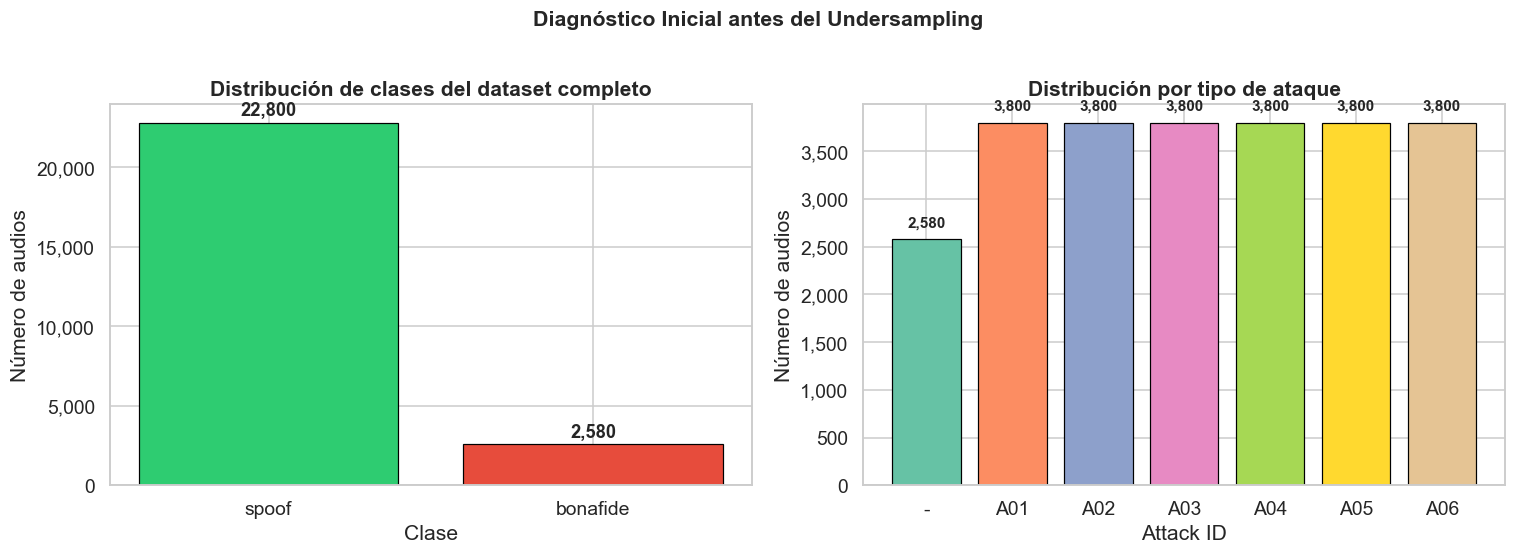

Nota: bonafide (voz humana real) - A01-A06 = audios generados por IA


In [14]:
#  BLOQUE 3 - visualización del desbalanceo inicial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: desbalanceo de las clases
counts = df_full['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución de clases del dataset completo')
axes[0].set_ylabel('Número de audios')
axes[0].set_xlabel('Clase')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Gráfico 2: distribución por attack_id
attack_counts = df_full['attack_id'].value_counts().sort_index()
palette = sns.color_palette('Set2', len(attack_counts))
bars2 = axes[1].bar(attack_counts.index, attack_counts.values, color=palette, edgecolor='black', linewidth=0.8)
axes[1].set_title('Distribución por tipo de ataque')
axes[1].set_ylabel('Número de audios')
axes[1].set_xlabel('Attack ID')
for bar, val in zip(bars2, attack_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Diagnóstico Inicial antes del Undersampling', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Nota: bonafide (voz humana real) - A01-A06 = audios generados por IA')

## **SECCIÓN 2: UNDERSAMPLING ESTRATIFICADO Y SEPARACIÓN TRAIN/TEST**

**PROBLEMA 1**: Por qué hacemos undersampling y no oversampling?

**DECISIÓN TOMADA 1**: el dataset tiene 22.800 spoof vs 2.580 bonafide. Existen dos filosofías:
- Oversampling (SMOTE): genera muestras sintéticas de la clase minoritaria. Haciendo esto hay el riesgo que los vectores interpolados pueden no corresponder a patrones acústicos reales.
- Undersampling: Reduce la clase mayoritaria. El riesgo es lo de perder información. Sin embargo, con 22.800 muestras spoof, pudimos seleccionar 2.500 representativas de todos los ataques (A01-A06) de forma estratificada, preservando la diversidad acústica.

Decidimos por hacer un undersampling estratificado, de manera tal que cada tipo de ataque esté representado proporcionalmente (`attack_id`). 
Si realizaramos un undersampling aleatorio sobre la clase spoof se podrian eliminar casi todos los registros de algún ataque específico (de algun modelo de IA especifico). Eligiendo hacer el **undersampling estratificado** por `attack_id`** garantizamos la distribución de las 2.500 muestras spoof proporcionalmente entre A01-A06.

**PROBLEMA 2**: Por qué 5.000 filas? 

**DECISIÓN TOMADA 2**: esta es nuestra hipótesis inicial. La Learning Curve nos dirá si esta cantidad es suficiente o si el modelo aún tiene margen de mejora con más datos. 5.000 es un punto de partida computacionalmente manejable que nos permite iterar rápido.

**PROBLEMA 3**: Por qué separar train/test antes del EDA?  

**DECISIÓN TOMADA 3**: analizar el dataset completo antes de dividir constituye Data Leakage, que significa que el conocimiento del conjunto de test contamina nuestras decisiones de preprocesamiento y feature engineering. El EDA debe replicar el escenario real: en producción, solo tenemos acceso a datos de entrenamiento.

### ***Bloque 4: undersampling estratificado por attack_id***

Como dicho antes, al tener 22.800 muestras spoof, un undersampling aleatorio podría eliminar casi todos los registros de algún ataque concreto (por ejemplo del A06), dejando al modelo sin exposición a ese tipo de ataque.

Adoptamos la solución de un undersampling estratificado por attack_id, distribuyendo las 2.500 muestras spoof proporcionalmente entre los 6 tipos de ataque.

Creamos un dataset de 5.000 audios, con 2.500 audios bonafide y 2.500 audios spoof (donde a cada algoritmo de IA corresponden 416 audios).

In [15]:
#  BLOQUE 4 - Undersampling estratificado por attack_id

# Separamos bonafide y spoof
df_bonafide = df_full[df_full['label'] == 'bonafide'].copy()
df_spoof    = df_full[df_full['label'] == 'spoof'].copy()

# Undersample BONAFIDE: tomamos min (todos los bonafide, N_PER_CLASS)
n_bonafide = min(len(df_bonafide), N_PER_CLASS)
df_bon_sample = df_bonafide.sample(n=n_bonafide, random_state=RANDOM_STATE)

# Undersample SPOOF: estratificado por attack_id (calculamos cuántas muestras tomar de cada ataque proporcionalmente
attack_counts = df_spoof['attack_id'].value_counts()
proportions   = attack_counts / attack_counts.sum()
n_spoof_total = N_PER_CLASS

# Distribuimos N_PER_CLASS entre los ataques
n_per_attack  = (proportions * n_spoof_total).astype(int)

# Ajustamos el redondeo para llegar exactamente a N_PER_CLASS
deficit = n_spoof_total - n_per_attack.sum()
for atk in n_per_attack.nlargest(abs(deficit)).index:
    n_per_attack[atk] += int(np.sign(deficit))

spoof_samples = []
for attack_id, n in n_per_attack.items():
    subset = df_spoof[df_spoof['attack_id'] == attack_id]
    n_take = min(n, len(subset))
    spoof_samples.append(subset.sample(n=n_take, random_state=RANDOM_STATE))

df_spoof_sample = pd.concat(spoof_samples)

# Dataset balanceado final
df_balanced = pd.concat([df_bon_sample, df_spoof_sample]).sample(
    frac=1, random_state=RANDOM_STATE
).reset_index(drop=True)


print(f'DATASET BALANCEADO: {df_balanced.shape[0]:,} filas × {df_balanced.shape[1]} columnas')
print('\n--- Distribución de clases tras undersampling ---')
print(df_balanced['label'].value_counts())
print('\n--- Distribución de attack_id en las muestras SPOOF ---')
print(df_balanced[df_balanced['label']=='spoof']['attack_id'].value_counts().sort_index())
print('\n--- Muestras por ataque (objetivo vs real) ---')
for atk, n in n_per_attack.items():
    real = (df_balanced['attack_id'] == atk).sum()
    print(f'  {atk}: objetivo={n} | obtenido={real}')

DATASET BALANCEADO: 5,000 filas × 37 columnas

--- Distribución de clases tras undersampling ---
label
bonafide    2500
spoof       2500
Name: count, dtype: int64

--- Distribución de attack_id en las muestras SPOOF ---
attack_id
A01    417
A02    417
A03    417
A04    417
A05    416
A06    416
Name: count, dtype: int64

--- Muestras por ataque (objetivo vs real) ---
  A01: objetivo=417 | obtenido=417
  A02: objetivo=417 | obtenido=417
  A03: objetivo=417 | obtenido=417
  A04: objetivo=417 | obtenido=417
  A05: objetivo=416 | obtenido=416
  A06: objetivo=416 | obtenido=416


### ***Bloque 5: separación train/test antes del EDA***

Si analizaramos el dataset completo antes de dividirlo, el conocimiento del conjunto de test contaminaría las decisiones de preprocesamiento y feature engineering. El EDA debe replicar el escenario real: en producción, solo tenemos acceso a datos de entrenamiento.

Entonces realizamos la separación entre conjunto de entrenamiento y de test antes del análisis exploratorio.

El resultado de nuestra separación (80% conjunto de entrenamiento - 20% conjunto de prueba) es la siguiente:

- ***CONJUNTO DE ENTRENAMIENTO (TRAIN)***: total muestras (4.000), Bonafide (2.000), Spoof (2.000)

- ***CONJUNTO DE PRUEBA (TEST)***: total muestras: (1.000), Bonafide (500), Spoof (500)

A partir de este punto, todo el EDA se realizará exclusivamente sobre el conjunto de train. El test lo recuperaremos al momento de hacer la evaluación final del modelo.

In [17]:
#  BLOQUE 5 - Separación train/test antes del EDA

# Definimos Features (X) y variable target (y)
# Excluimos: file_name (identificador), attack_id (info de grupo) y la variable target (label)
FEATURE_COLS = [c for c in df_balanced.columns if c not in ['file_name', 'attack_id', 'label']]
TARGET_COL   = 'label'

X = df_balanced[FEATURE_COLS]
y = df_balanced[TARGET_COL]

# Separación estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Reconstruimos DataFrames con metadatos para el EDA
train_meta = df_balanced.loc[X_train.index].copy()
test_meta  = df_balanced.loc[X_test.index].copy()

print('SEPARACIÓN TRAIN / TEST COMPLETADA')
print(f'  Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'  Features utilizadas: {len(FEATURE_COLS)}')
print()
print('--- Distribución de clases en TRAIN ---')
print(y_train.value_counts())
print('\n--- Distribución de clases en TEST ---')
print(y_test.value_counts())

print('A partir de aquí, el EDA se realizará excusivamente sobre el conjunto de train')

SEPARACIÓN TRAIN / TEST COMPLETADA
  Train: 4,000 filas | Test: 1,000 filas
  Features utilizadas: 34

--- Distribución de clases en TRAIN ---
label
spoof       2000
bonafide    2000
Name: count, dtype: int64

--- Distribución de clases en TEST ---
label
bonafide    500
spoof       500
Name: count, dtype: int64
A partir de aquí, el EDA se realizará excusivamente sobre el conjunto de train


## **SECCIÓN 3: EDA SOBRE CONJUNTO DE TRAIN**

### ***Bloque 6: estadísticas descriptivas del conjunto de Train***

Para cada feature calculamos las estadísticas básicas: media, desviación estándar y percentiles (25%, 50%, 75%). Además, calculamos el coeficiente de variación (CV%) de cada feature, que solo mide la dispersión global de las features, sin importar las clases (no sabe nada de bonafide ni spoof).

Si una feature tiene un CV% muy bajo, todos los valores son similares entre sí, entonces tanto bonafide como spoof tendrán valores parecidos y la feature no sirve para distinguir entre las clases. En cambio, si una feature tiene un coeficiente de variación elevado, los valores varían mucho y hay más posibilidad de que esa variación esté correlacionada con la clase y entonces que nos aporte información relevante a la hora de predecir la clase.

Las features con mayor CV% (excluyendo signal_mean) son:

1) **mfcc_3_mean**: 356.9 (alta dispersión - potencialmente muy discriminativa)
2) **mfcc_6_mean**: 149.3 (dispersión considerable)
3) **mfcc_5_mean**: 117.0 (dispersión considerable)
4) **mfcc_12_mean**: 95.2 (dispersión moderada/alta)
5) **mfcc_13_mean**: 70.9 (dispersión moderada)

Estas features son las candidatas más prometedoras a priori para separar voz real de voz sintética, aunque la confirmación definitiva vendrá del modelo y del análisis de importancia de features en los pasos siguientes.

Descartamos el CV% de signal_mean (1406.7) porque es artificialmente alto y no debe interpretarse como que es la feature más discriminativa. Esto ocurre porque su media es casi cero, lo que hace que cualquier pequeña desviación genere un cociente enorme. En estos casos el CV% no es un indicador fiable.

In [18]:
#  BLOQUE 6 - estadísticas descriptivas del conjunto de Train
print('ESTADÍSTICAS DESCRIPTIVAS DEL CONJUNTO DE TRAIN')
print(f'Filas: {X_train.shape[0]:,} | Features: {X_train.shape[1]}')
print()

stats = X_train.describe().T
stats['cv%'] = (stats['std'] / stats['mean'].abs() * 100).round(1)  # Coeficiente de variación
display(stats.round(4))

print()
print('--- Features con mayor coeficiente de variación (más discriminativas a priori) ---')
display(stats['cv%'].sort_values(ascending=False).head(10))

ESTADÍSTICAS DESCRIPTIVAS DEL CONJUNTO DE TRAIN
Filas: 4,000 | Features: 34



,count,mean,std,min,25%,50%,75%,max,cv%
signal_mean,4000.0,0.0000,0.0000,-0.0002,-0.0000,0.0000,0.0000,0.0001,1406.7
signal_std,4000.0,0.1203,0.0303,0.0440,0.0987,0.1171,0.1377,0.2746,25.2
rmse_mean,4000.0,0.0848,0.0292,0.0232,0.0641,0.0799,0.1004,0.2440,34.5
zcr_mean,4000.0,0.1220,0.0330,0.0253,0.0985,0.1201,0.1430,0.2565,27.0
tempo_bpm,4000.0,126.2216,35.5530,48.0769,98.6842,125.0000,144.2308,312.5000,28.2
mfcc_1_mean,4000.0,-304.0206,50.9705,-471.8865,-339.7658,-306.0808,-266.8216,-158.0690,16.8
mfcc_1_std,4000.0,150.4470,24.8065,68.4612,135.3588,152.2297,167.4073,217.5712,16.5
mfcc_2_mean,4000.0,70.1502,18.6953,16.0121,57.2187,67.6338,81.2083,151.5380,26.7
mfcc_2_std,4000.0,50.6473,9.6992,17.5136,44.1424,49.9387,56.6048,99.8094,19.2
mfcc_3_mean,4000.0,-3.1840,11.3639,-50.5858,-10.1463,-2.2861,4.5022,31.5695,356.9



--- Features con mayor coeficiente de variación (más discriminativas a priori) ---


signal_mean     1406.7
mfcc_3_mean      356.9
mfcc_6_mean      149.3
mfcc_5_mean      117.0
mfcc_12_mean      95.2
mfcc_13_mean      70.9
mfcc_7_mean       60.6
mfcc_11_mean      59.8
mfcc_10_mean      57.9
mfcc_9_mean       57.1
Name: cv%, dtype: float64

### ***Bloque 7: distribución de la variable objetivo en el conjunto de train***

En este bloque confirmamos visualmente que el conjunto de train quedó perfectamente balanceado (2.000/2.000) y que todos los attack_id están representados con muestras suficientes.

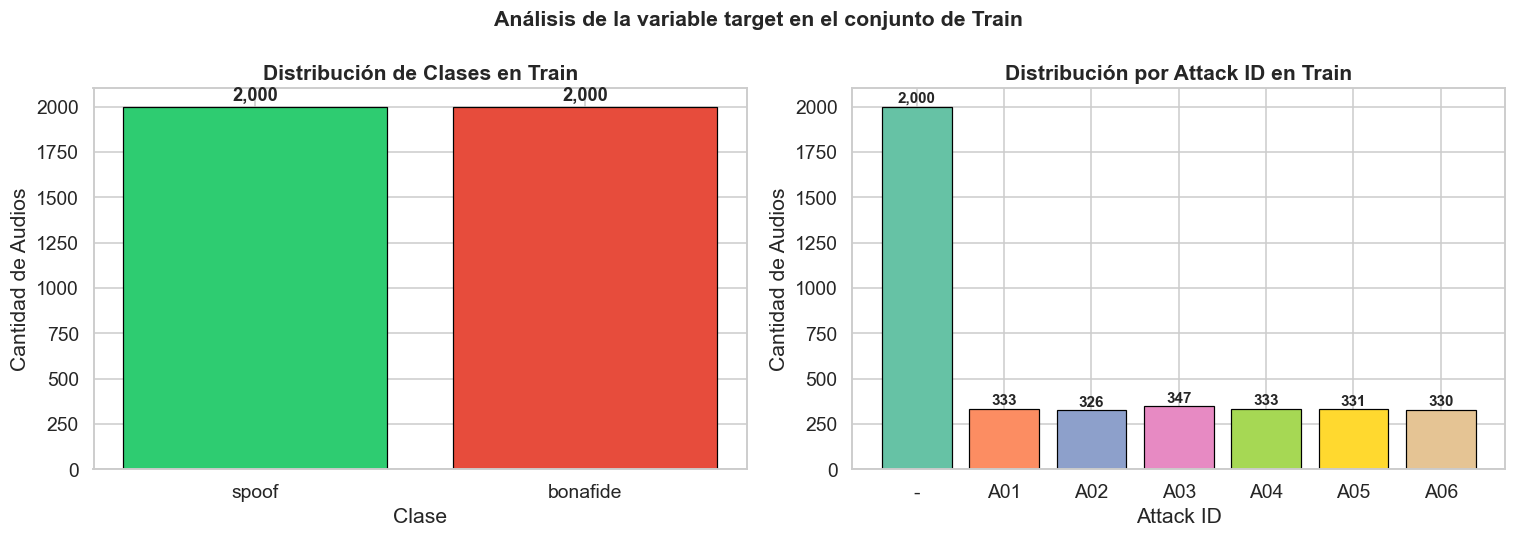

In [20]:
#  BLOQUE 7 - distribución de la variable objetivo en el conjunto de train

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de clases en el conjunto de Train
label_train = y_train.value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(label_train.index, label_train.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribución de Clases en Train')
axes[0].set_ylabel('Cantidad de Audios')
axes[0].set_xlabel('Clase')
for bar, val in zip(bars, label_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Distribución de attack_id en el conjunto de Train
atk_train = train_meta['attack_id'].value_counts().sort_index()
palette   = sns.color_palette('Set2', len(atk_train))
bars2     = axes[1].bar(atk_train.index, atk_train.values, color=palette, edgecolor='black', linewidth=0.8)
axes[1].set_title('Distribución por Attack ID en Train')
axes[1].set_ylabel('Cantidad de Audios')
axes[1].set_xlabel('Attack ID')
for bar, val in zip(bars2, atk_train.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Análisis de la variable target en el conjunto de Train', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ***Bloque 8: análisis de Nans y valores duplicados***

Comprobamos si hay valores nulos en alguna feature, contamos las filas duplicadas y mostramos el rango (mínimo y máximo) de cada feature.

El resultado es que no hay valores nulos ni duplicados, entonces no hicimos ninguna acción de limpieza. El dataset está listo para el análisis.

In [24]:
#  BLOQUE 8 - valores Nans y duplicados en el conjunto de Train
nulls_train = X_train.isnull().sum()
print(nulls_train[nulls_train > 0] if nulls_train.sum() > 0 else 'No hay valores nulos en el conjunto de train')

n_dups = X_train.duplicated().sum()
print(f'Filas duplicadas: {n_dups}')
if n_dups > 0:
    print('ATENCIÓN: Se detectaron duplicados. Evaluar de eliminarlos antes del entrenamiento del modelo')

print('--- RANGO DE VALORES POR FEATURE (MIN/MAX) ---')
ranges = pd.DataFrame({'min': X_train.min(), 'max': X_train.max()})
display(ranges.T)

No hay valores nulos en el conjunto de train
Filas duplicadas: 0
--- RANGO DE VALORES POR FEATURE (MIN/MAX) ---


,signal_mean,signal_std,rmse_mean,zcr_mean,tempo_bpm,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,...,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean
min,-0.000202,0.043956,0.023173,0.025267,48.076923,-471.88650,68.461205,16.012133,17.513632,-50.585810,...,3.525668,-29.947697,3.987968,-18.939114,3.853358,-27.674520,3.247302,766.143342,841.430706,1518.110795
max,0.000057,0.274598,0.244048,0.256474,312.500000,-158.06905,217.571230,151.537950,99.809410,31.569496,...,25.333279,8.957898,18.941141,13.295913,18.851803,6.943151,17.584156,2800.262165,2087.419461,5110.748626


### ***Bloque 9: Boxplots de Features de señal y espectrales por clase***

Hicimos boxplots comparando la distribución de las 8 features no-MFCC entre bonafide y spoof: `signal_mean`, `signal_std`, `rmse_mean`, `zcr_mean`, `tempo_bpm`, `spectral_centroid_mean`, `spectral_bandwidth_mean`, `spectral_rolloff_mean`.

A través de los boxplots vamos a ver visualmente si las distribuciones de cada clase se solapan o se separan. Si las cajas no se solapan, la feature es potencialmente discriminativa. 

Estamos buscando features donde las distribuciones de `bonafide` y `spoof` sean visualmente separables: esas serán las más predictivas.

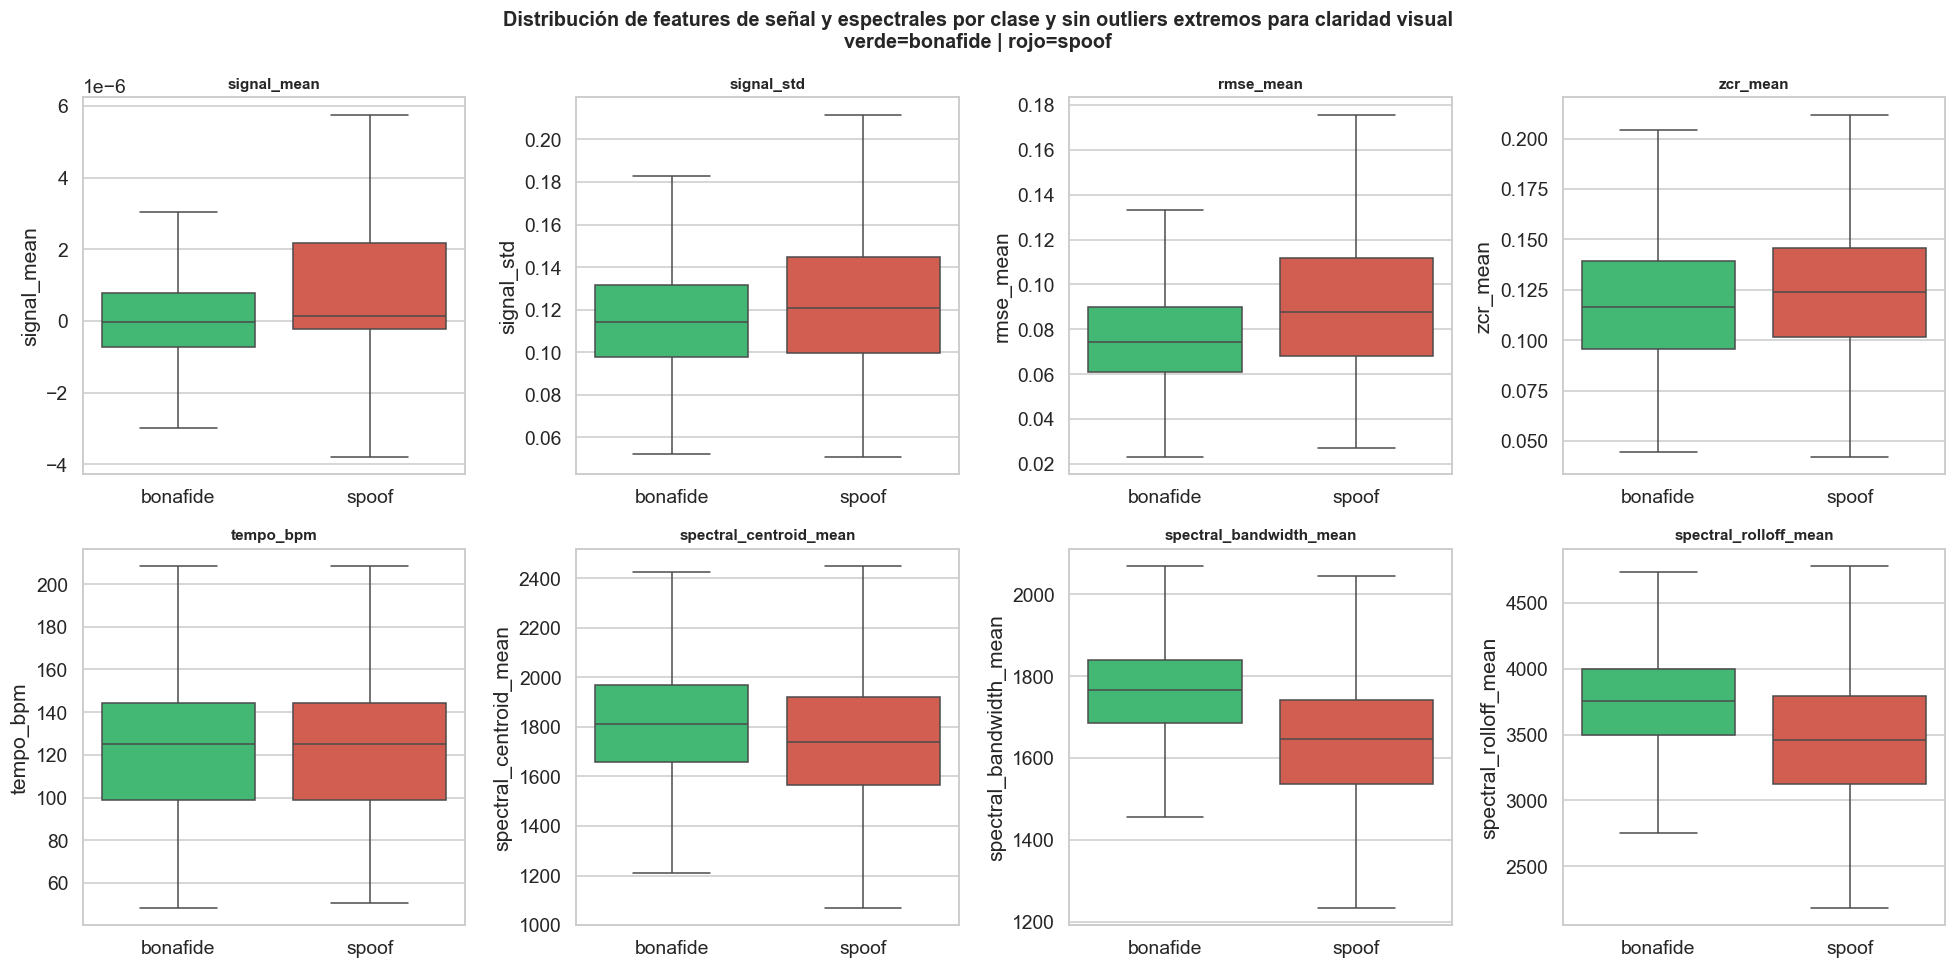

In [29]:
#  BLOQUE 9 - Boxplots de Features de señal y espectrales por clase

train_plot = X_train.copy()
train_plot['label'] = y_train.values

# Features no-MFCC
non_mfcc_features = ['signal_mean', 'signal_std', 'rmse_mean', 'zcr_mean', 'tempo_bpm',
                      'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean']
non_mfcc_available = [f for f in non_mfcc_features if f in train_plot.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(non_mfcc_available):
    sns.boxplot(
        data=train_plot, x='label', y=feat,
        order=['bonafide', 'spoof'],
        palette=['#2ecc71', '#e74c3c'],
        ax=axes[i], showfliers=False
    )
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')

# Ocultar ejes sobrantes
for j in range(len(non_mfcc_available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de features de señal y espectrales por clase y sin outliers extremos para claridad visual\nverde=bonafide | rojo=spoof', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ***Bloque 10: Boxplots: MFCC means por clase***

Ahora generamos los boxplots de los 13 coeficientes MFCC (medias), de `mfcc_1_mean` a `mfcc_13_mean`. Los generamos en una cuadrícula 3×5 para verlos todos juntos y comparar cuáles MFCCs separan mejor las clases.

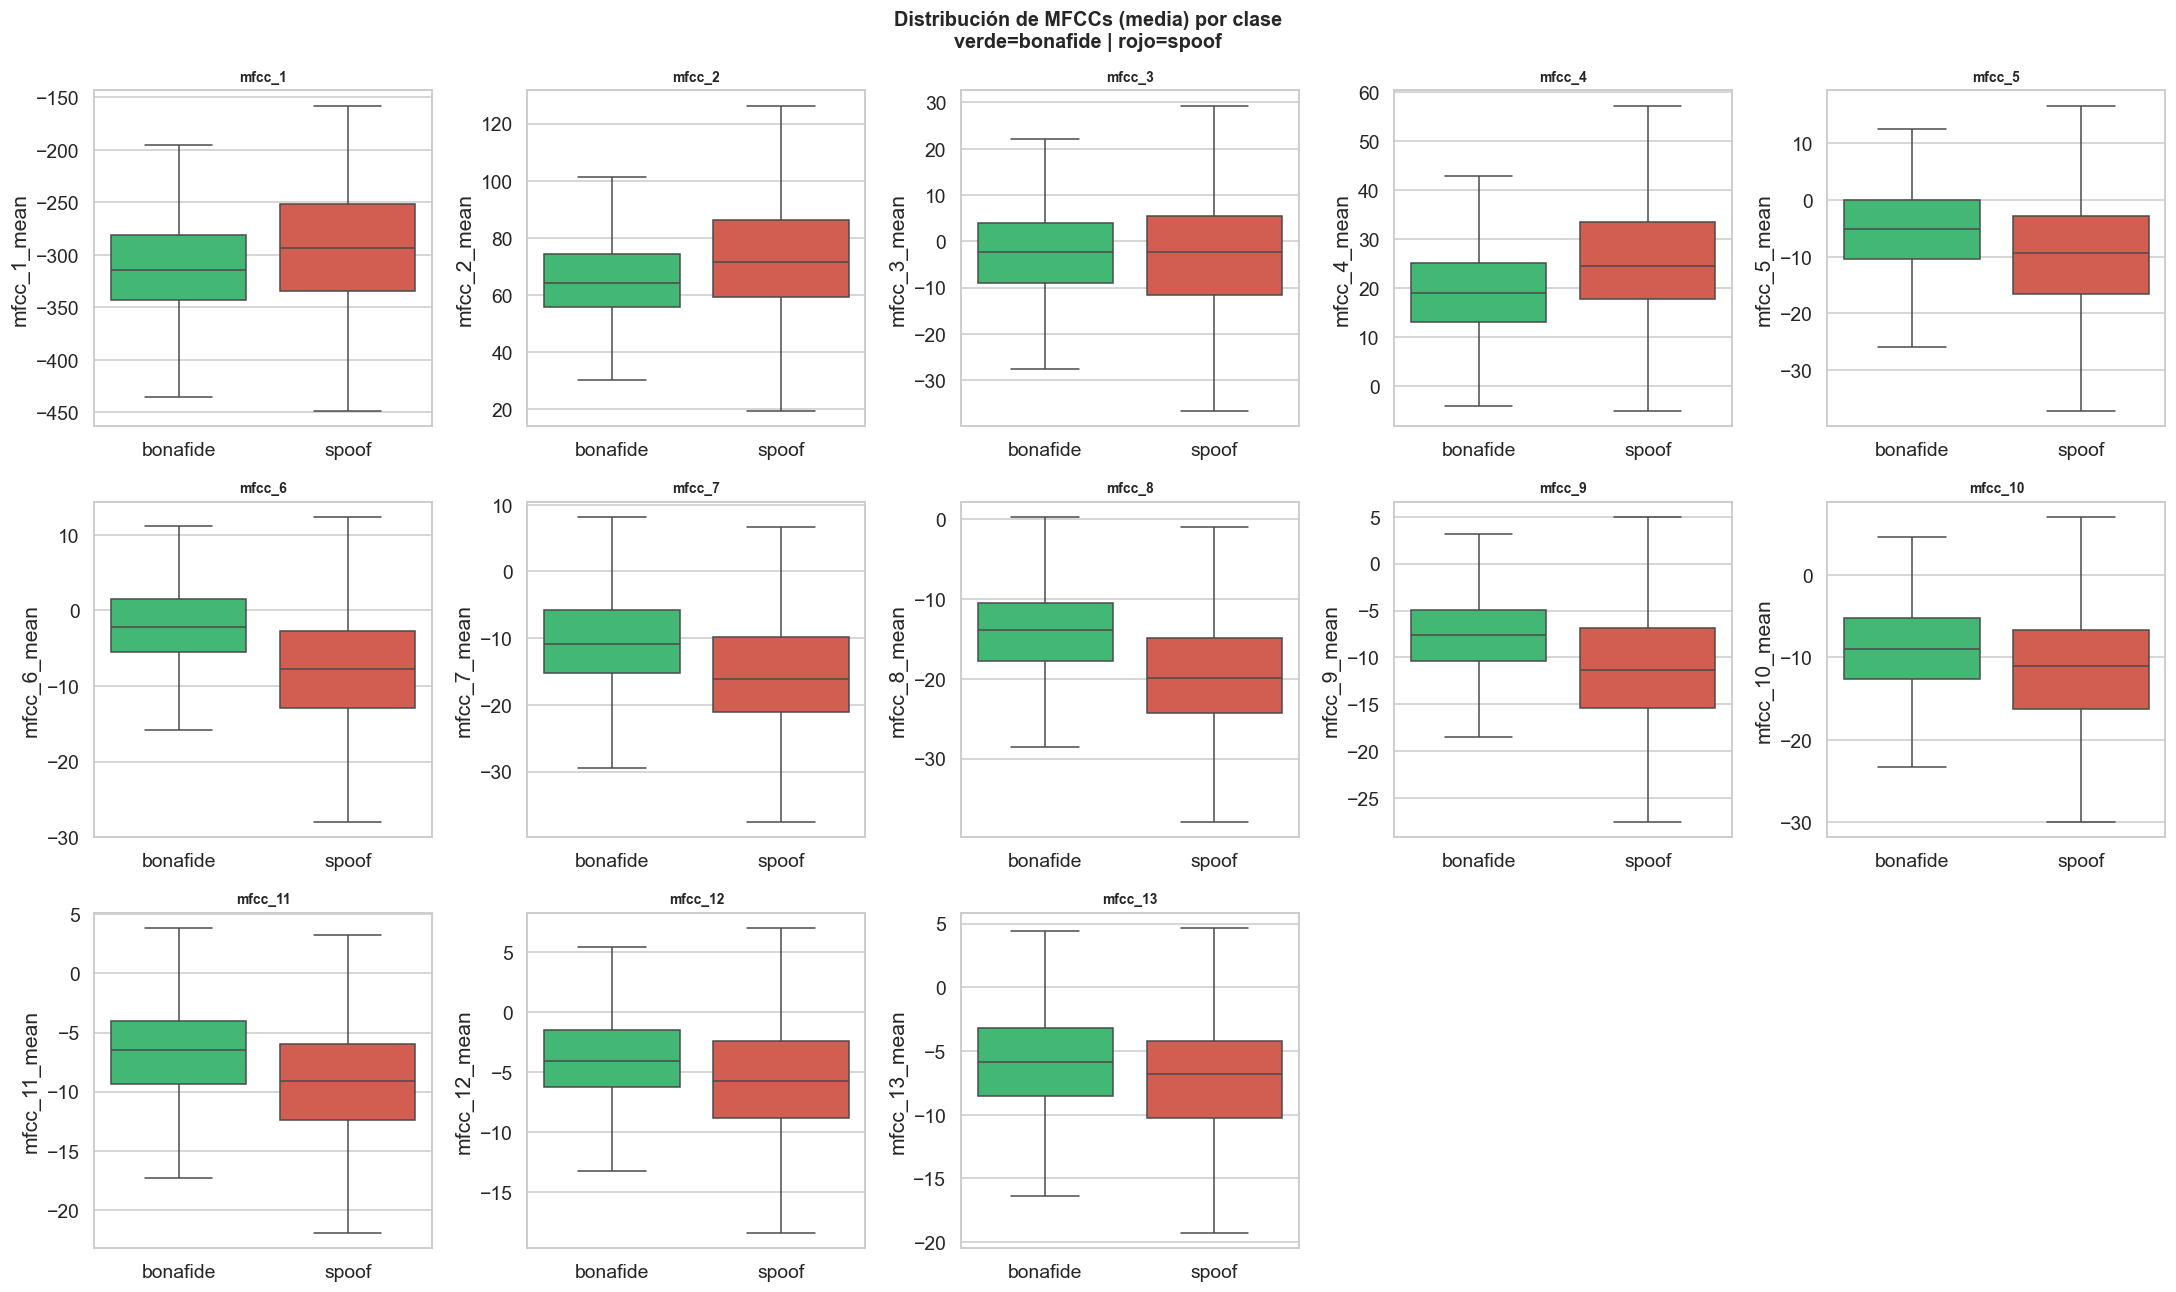

In [30]:
#  BLOQUE 10 - BOXPLOTS: MFCC MEANS POR CLASE
mfcc_mean_cols = [c for c in FEATURE_COLS if c.endswith('_mean') and 'mfcc' in c]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(mfcc_mean_cols):
    sns.boxplot(
        data=train_plot, x='label', y=feat,
        order=['bonafide', 'spoof'],
        palette=['#2ecc71', '#e74c3c'],
        ax=axes[i], showfliers=False
    )
    axes[i].set_title(feat.replace('_mean', ''), fontsize=9)
    axes[i].set_xlabel('')

for j in range(len(mfcc_mean_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de MFCCs (media) por clase\nverde=bonafide | rojo=spoof',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ***Bloque 11: Boxplots: MFCC stds por clase***

Realizamos el mismo análisis de boxplots para las desviaciones estándar de los 13 MFCCs, desde `mfcc_1_std` a `mfcc_13_std`.

Las desviaciones estándar capturan la variabilidad temporal del coeficiente dentro de cada audio. Una voz sintética puede tener una media similar a la real pero una std diferente (por ejemplo, menos variación temporal).

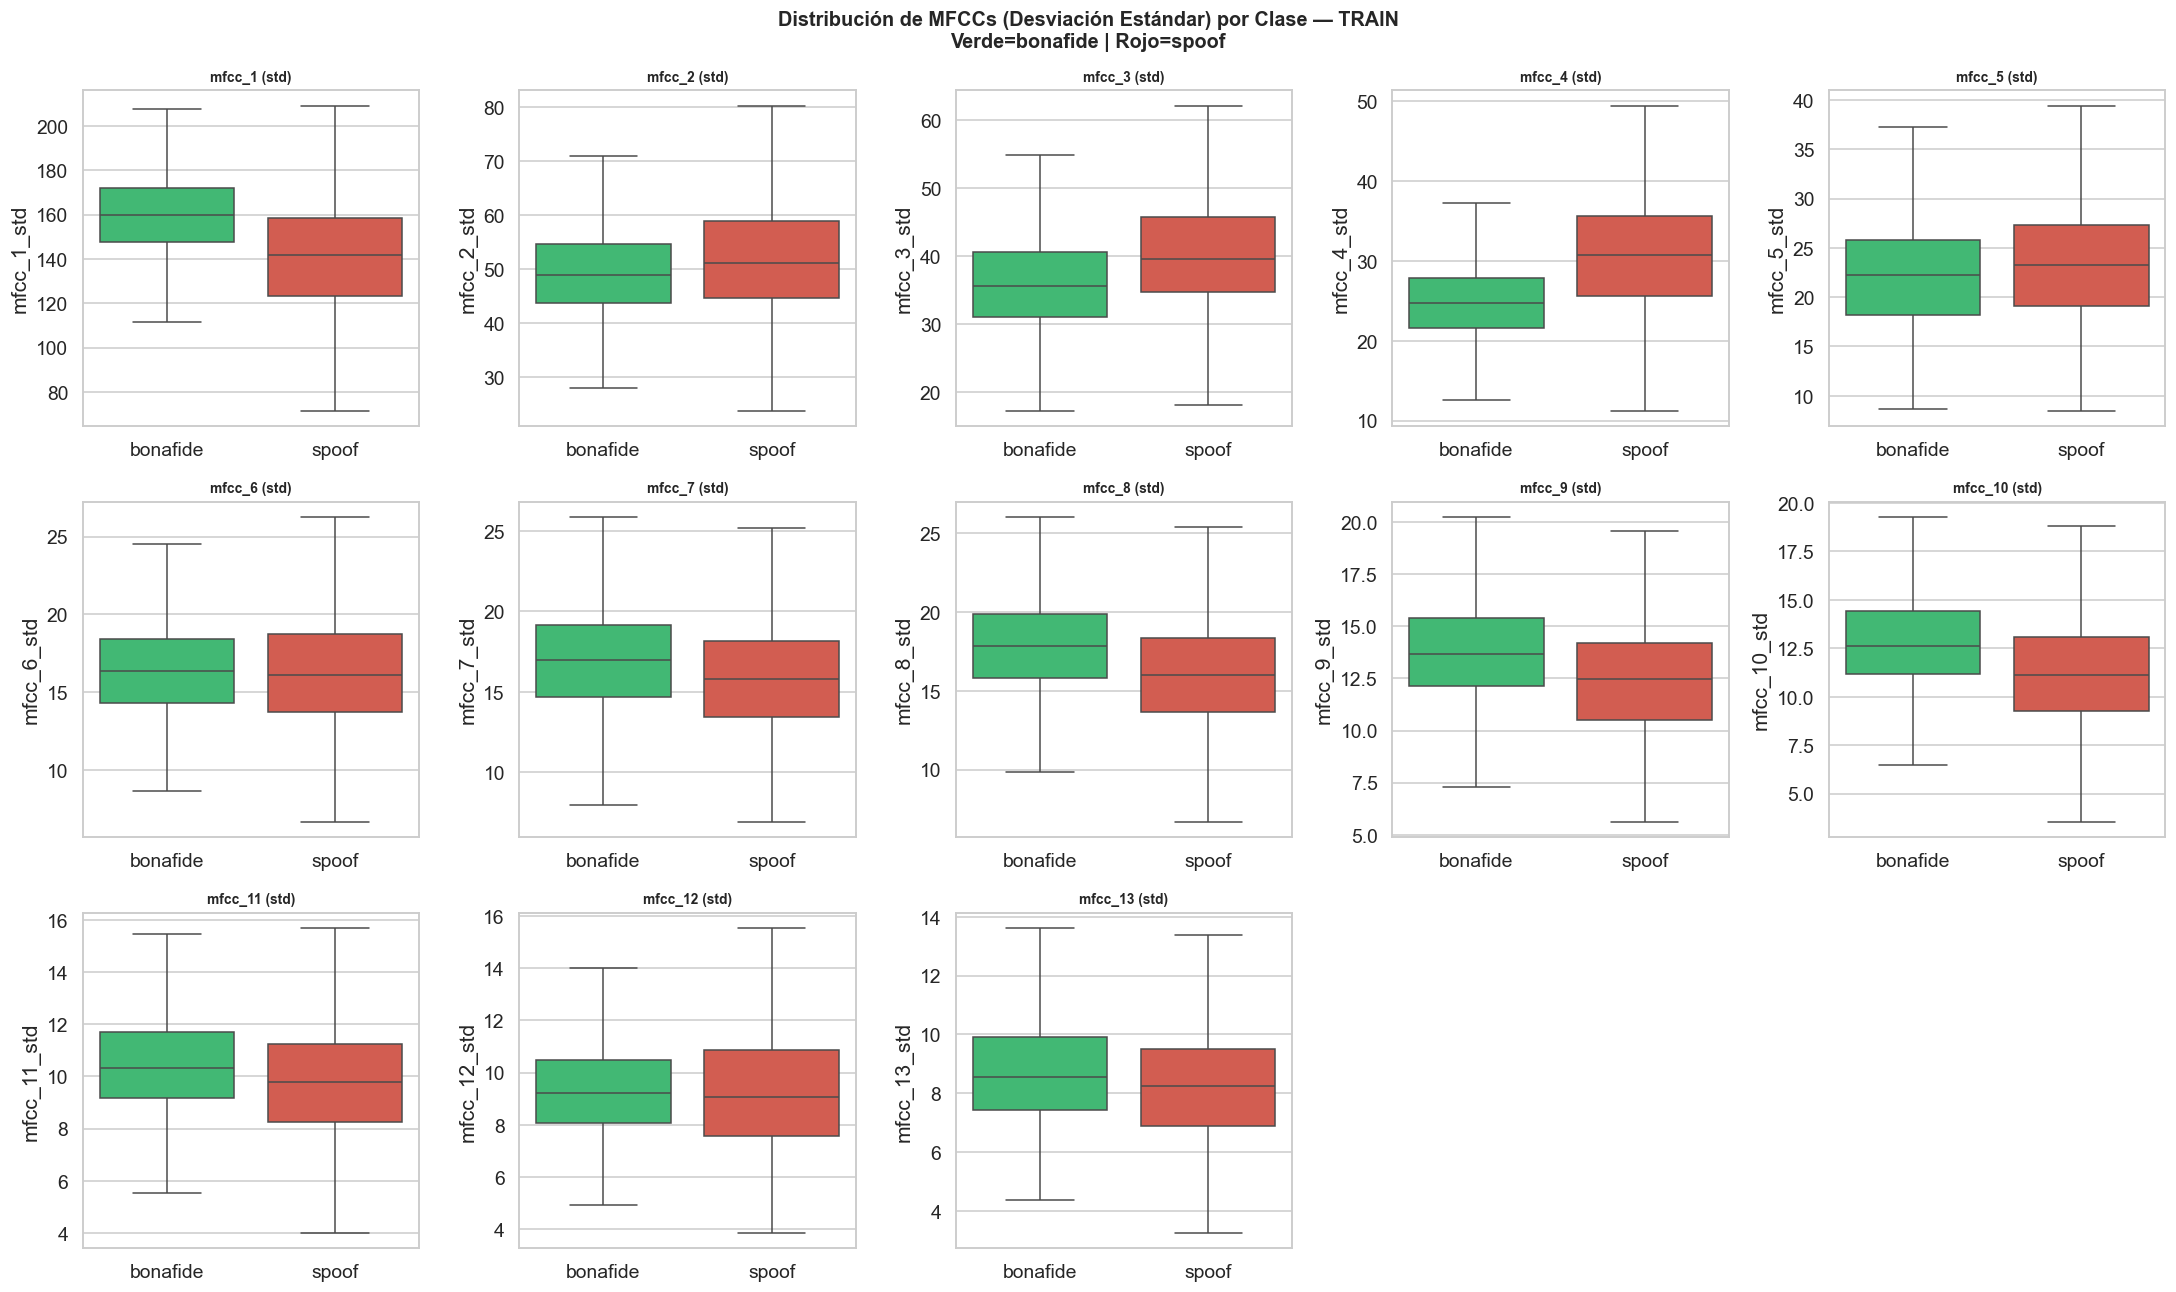

In [32]:
#  BLOQUE 11 - BOXPLOTS: MFCC STDs POR CLASE

mfcc_std_cols = [c for c in FEATURE_COLS if c.endswith('_std') and 'mfcc' in c]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(mfcc_std_cols):
    sns.boxplot(
        data=train_plot, x='label', y=feat,
        order=['bonafide', 'spoof'],
        palette=['#2ecc71', '#e74c3c'],
        ax=axes[i], showfliers=False
    )
    axes[i].set_title(feat.replace('_std', ' (std)'), fontsize=9)
    axes[i].set_xlabel('')

for j in range(len(mfcc_std_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de MFCCs (Desviación Estándar) por Clase — TRAIN\nVerde=bonafide | Rojo=spoof',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# LLEGUÉ HASTA AQUI!

### 3.5 — Separabilidad Cuantitativa: Efecto-Tamaño por Feature

Para rankear objetivamente qué features separan mejor las clases, calculamos el **Coeficiente d de Cohen**, que mide cuántas desviaciones estándar separan las medias de bonafide y spoof. Valores > 0.8 = efecto grande (features prioritarias).

In [12]:
# ============================================================
#  BLOQUE 12 — EFECTO-TAMAÑO (COHEN'S d) POR FEATURE
# ============================================================
def cohen_d(group1, group2):
    """Calcula el d de Cohen entre dos grupos (magnitud del efecto)."""
    n1, n2  = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return abs(group1.mean() - group2.mean()) / (pooled_std + 1e-9)

bon_train   = train_plot[train_plot['label'] == 'bonafide'][FEATURE_COLS]
spoof_train = train_plot[train_plot['label'] == 'spoof'][FEATURE_COLS]

effect_sizes = {}
for col in FEATURE_COLS:
    effect_sizes[col] = cohen_d(bon_train[col], spoof_train[col])

effect_df = pd.DataFrame.from_dict(effect_sizes, orient='index', columns=['cohen_d'])
effect_df = effect_df.sort_values('cohen_d', ascending=False)

# Clasificación
effect_df['magnitud'] = pd.cut(
    effect_df['cohen_d'],
    bins=[0, 0.2, 0.5, 0.8, np.inf],
    labels=['Pequeño (<0.2)', 'Mediano (0.2-0.5)', 'Grande (0.5-0.8)', 'Muy Grande (>0.8)']
)

print('TOP 15 FEATURES POR PODER DISCRIMINATIVO (d de Cohen):')
display(effect_df.head(15))

print(f"\nFeatures con efecto MUY GRANDE (d > 0.8): {(effect_df['cohen_d'] > 0.8).sum()}")
print(f"Features con efecto GRANDE (0.5 < d ≤ 0.8): {((effect_df['cohen_d'] > 0.5) & (effect_df['cohen_d'] <= 0.8)).sum()}")
print(f"Features con efecto PEQUEÑO (d < 0.2): {(effect_df['cohen_d'] < 0.2).sum()}")

TOP 15 FEATURES POR PODER DISCRIMINATIVO (d de Cohen):


,cohen_d,magnitud
mfcc_4_std,0.983692,Muy Grande (>0.8)
spectral_bandwidth_mean,0.891306,Muy Grande (>0.8)
mfcc_1_std,0.842659,Muy Grande (>0.8)
mfcc_8_mean,0.835458,Muy Grande (>0.8)
mfcc_6_mean,0.801108,Muy Grande (>0.8)
mfcc_9_mean,0.689442,Grande (0.5-0.8)
mfcc_7_mean,0.659045,Grande (0.5-0.8)
mfcc_4_mean,0.635537,Grande (0.5-0.8)
spectral_rolloff_mean,0.631137,Grande (0.5-0.8)
mfcc_3_std,0.597893,Grande (0.5-0.8)



Features con efecto MUY GRANDE (d > 0.8): 5
Features con efecto GRANDE (0.5 < d ≤ 0.8): 11
Features con efecto PEQUEÑO (d < 0.2): 8


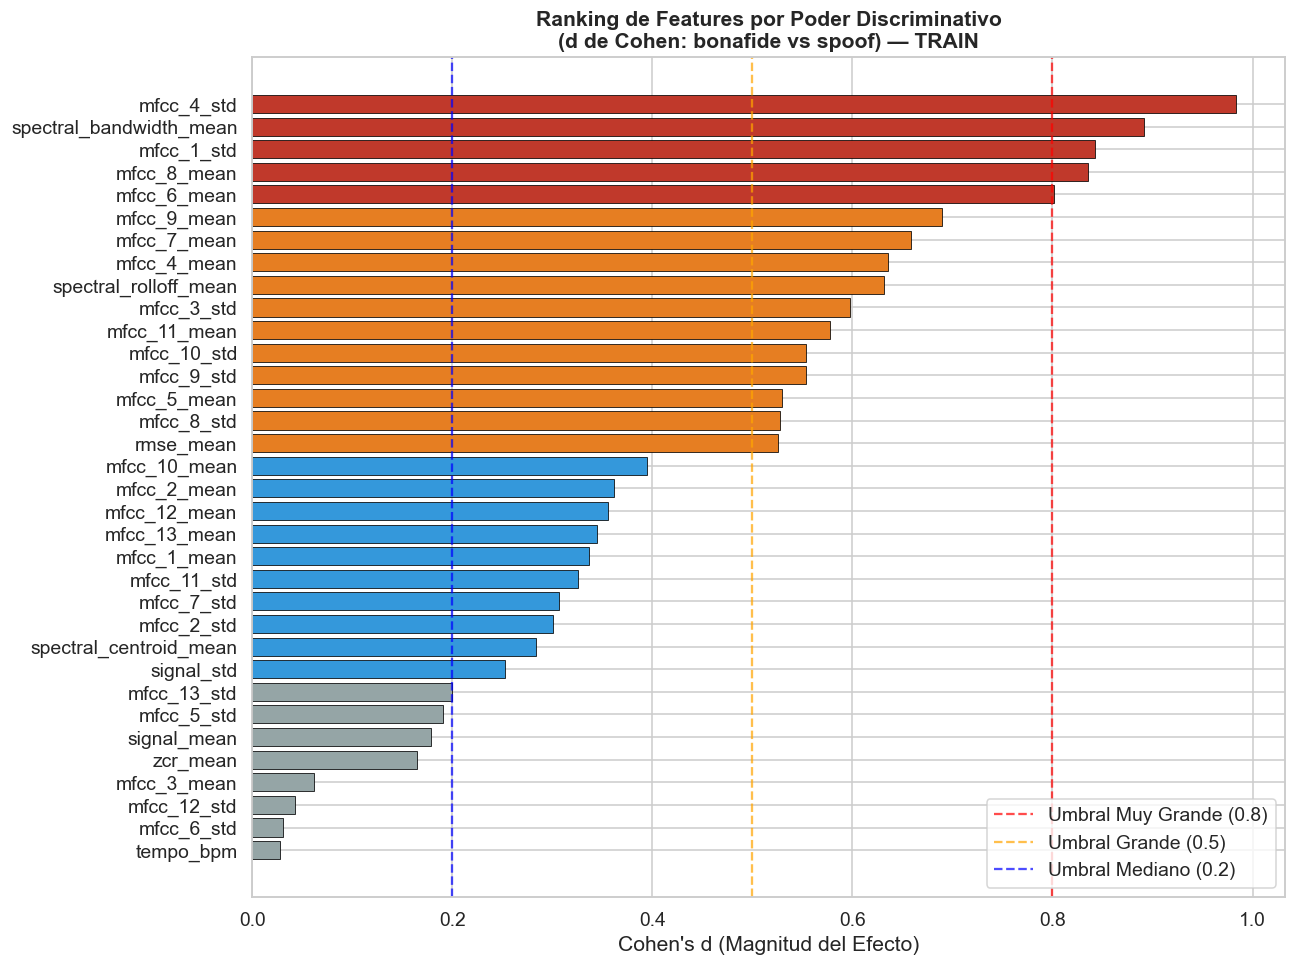

Interpretación: A mayor Cohen's d, mayor separación entre bonafide y spoof.
Features rojas serán las más relevantes para el modelo.


In [13]:
# ============================================================
#  BLOQUE 13 — VISUALIZACIÓN RANKING COHEN'S d
# ============================================================
fig, ax = plt.subplots(figsize=(12, 9))

color_map = {
    'Muy Grande (>0.8)': '#c0392b',
    'Grande (0.5-0.8)':  '#e67e22',
    'Mediano (0.2-0.5)': '#3498db',
    'Pequeño (<0.2)':    '#95a5a6'
}
colors = effect_df['magnitud'].map(color_map).fillna('#95a5a6')

bars = ax.barh(effect_df.index, effect_df['cohen_d'], color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0.8, color='red',    linestyle='--', alpha=0.7, label='Umbral Muy Grande (0.8)')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='Umbral Grande (0.5)')
ax.axvline(x=0.2, color='blue',   linestyle='--', alpha=0.7, label='Umbral Mediano (0.2)')

ax.set_xlabel("Cohen's d (Magnitud del Efecto)")
ax.set_title("Ranking de Features por Poder Discriminativo\n(d de Cohen: bonafide vs spoof) — TRAIN",
             fontweight='bold')
ax.invert_yaxis()
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('Interpretación: A mayor Cohen\'s d, mayor separación entre bonafide y spoof.')
print('Features rojas serán las más relevantes para el modelo.')

### 3.6 — Matriz de Correlación entre Features

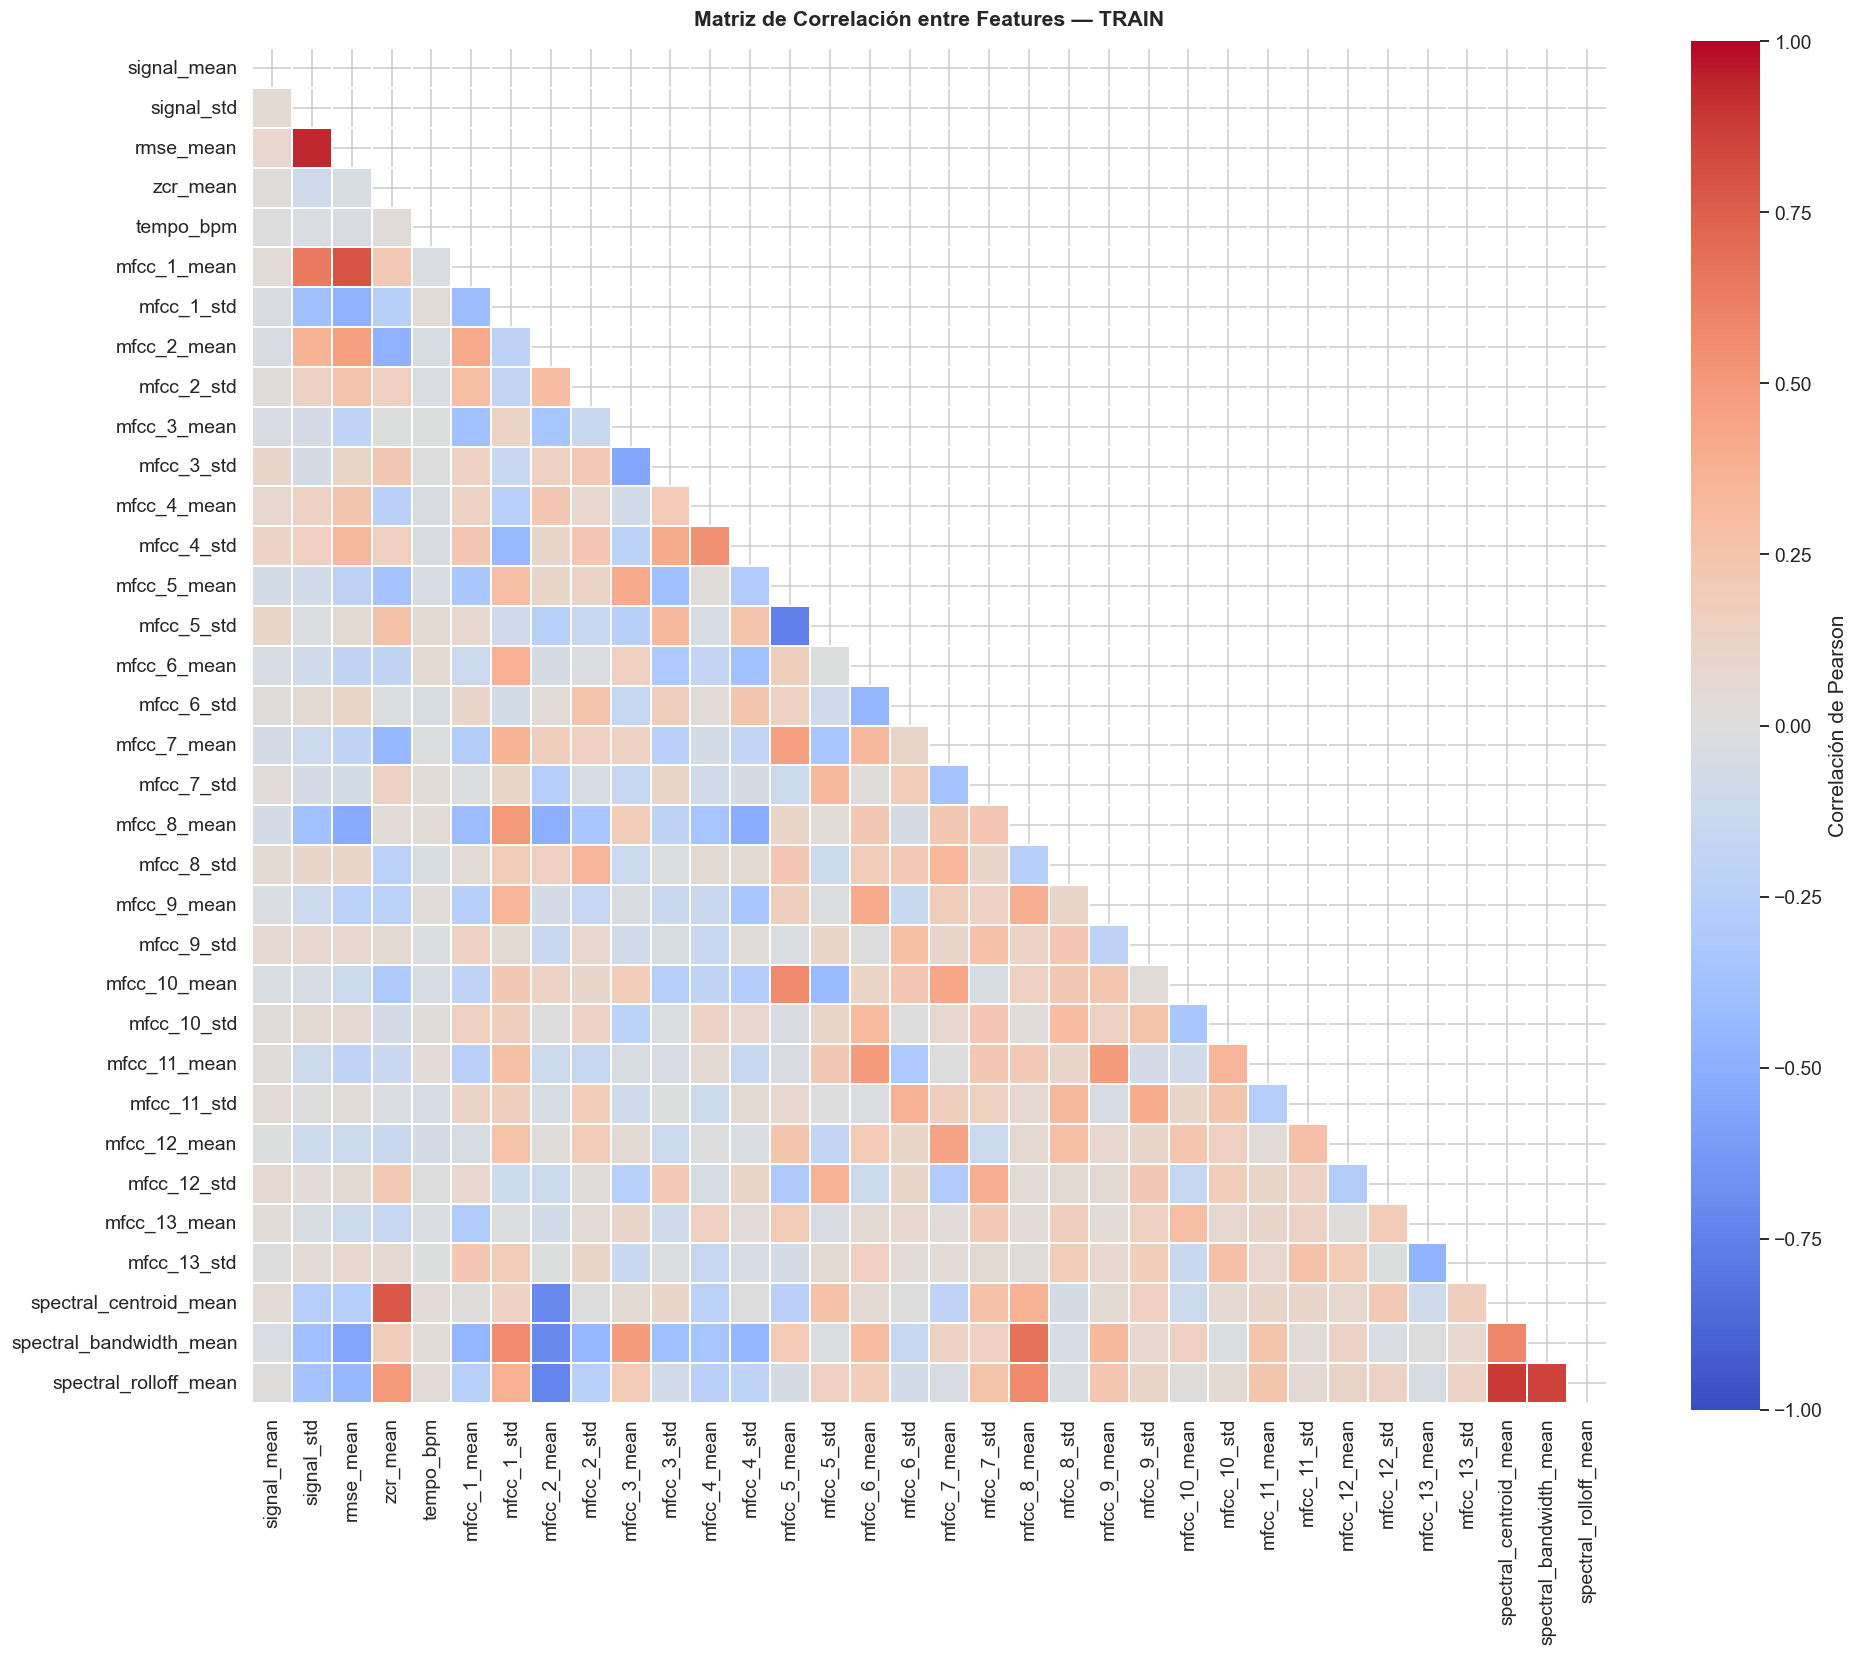

--- PARES DE FEATURES CON CORRELACIÓN ABSOLUTA > 0.85 (posible redundancia) ---


,Feature_A,Feature_B,Correlacion
0,signal_std,rmse_mean,0.934
1,spectral_centroid_mean,spectral_rolloff_mean,0.879
2,spectral_bandwidth_mean,spectral_rolloff_mean,0.859


In [14]:
# ============================================================
#  BLOQUE 14 — MATRIZ DE CORRELACIÓN (TRAIN)
# ============================================================
corr_matrix = X_train.corr(method='pearson')

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Correlación de Pearson'}
)
ax.set_title('Matriz de Correlación entre Features — TRAIN', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Pares con alta correlación (posible redundancia)
print('--- PARES DE FEATURES CON CORRELACIÓN ABSOLUTA > 0.85 (posible redundancia) ---')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.85:
            high_corr_pairs.append({
                'Feature_A': corr_matrix.columns[i],
                'Feature_B': corr_matrix.columns[j],
                'Correlacion': round(val, 3)
            })

if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs).sort_values('Correlacion', key=abs, ascending=False))
else:
    print('No se encontraron pares con correlación > 0.85.')

### 3.7 — Análisis por Tipo de Ataque: ¿Son todos los ataques igualmente difíciles de detectar?

PERFIL ACÚSTICO MEDIO POR TIPO DE ATAQUE (top features — TRAIN):


,mfcc_4_std,spectral_bandwidth_mean,mfcc_1_std,mfcc_8_mean,mfcc_6_mean,mfcc_9_mean,mfcc_7_mean,mfcc_4_mean
attack_id,,,,,,,,
-,24.836,1760.270,160.080,-14.307,-2.257,-7.615,-10.606,18.977
A01,35.995,1405.505,109.810,-25.885,-13.368,-13.449,-15.615,28.908
A02,32.420,1655.242,144.158,-21.202,-10.377,-13.780,-16.255,30.159
A03,37.320,1678.262,146.852,-20.402,-5.795,-8.796,-15.140,34.726
A04,28.339,1605.668,140.328,-19.395,-7.743,-13.601,-17.611,21.594
A05,28.444,1665.340,137.674,-19.192,-6.717,-12.177,-16.352,18.081
A06,21.777,1788.885,166.090,-10.836,-3.467,-4.898,-12.484,20.823


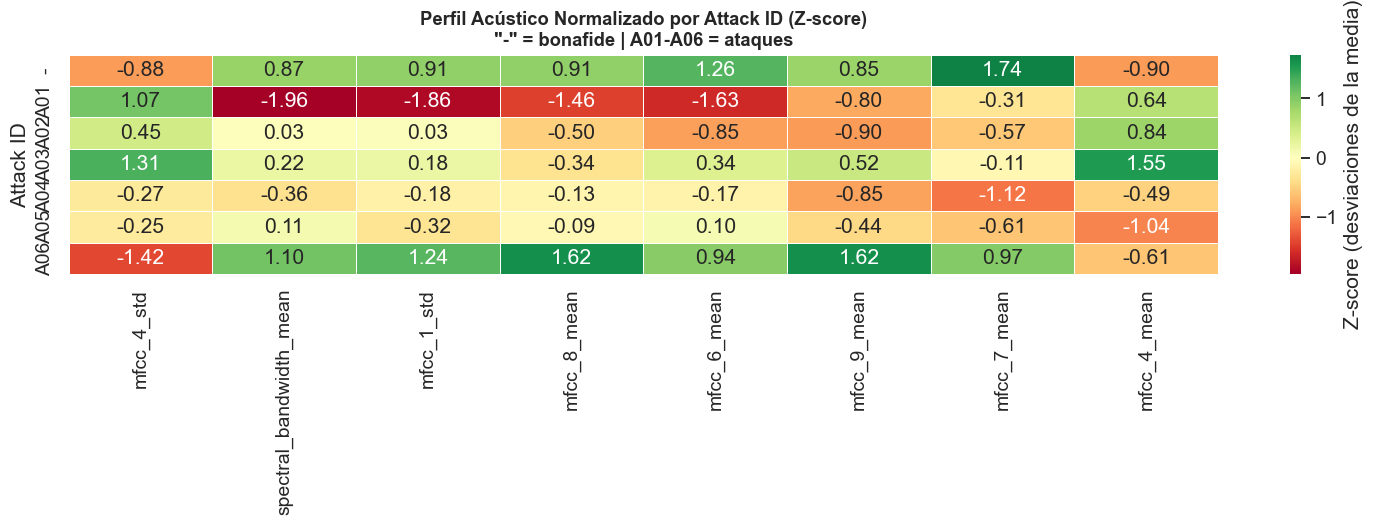


Interpretación: Filas con perfil muy diferente al "-" (bonafide) son más fáciles de detectar.
Filas con perfil similar al bonafide son ataques más sofisticados (mayor desafío para el modelo).


In [15]:
# ============================================================
#  BLOQUE 15 — PERFIL ACÚSTICO POR ATTACK_ID
#             (Comparar las medias de features clave por ataque)
# ============================================================
# Tomamos las top features con mayor Cohen's d
top_features = effect_df.head(8).index.tolist()

train_meta_indexed = train_meta.copy()
train_meta_indexed = train_meta_indexed.reset_index(drop=True)

# Perfil de medias por attack_id (incluyendo bonafide como '-')
profile = train_meta_indexed.groupby('attack_id')[top_features].mean()

print('PERFIL ACÚSTICO MEDIO POR TIPO DE ATAQUE (top features — TRAIN):')
display(profile.round(3))

# Heatmap de perfiles
fig, ax = plt.subplots(figsize=(14, 5))
profile_normalized = (profile - profile.mean()) / (profile.std() + 1e-9)  # Z-score para comparabilidad
sns.heatmap(
    profile_normalized,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Z-score (desviaciones de la media)'}
)
ax.set_title('Perfil Acústico Normalizado por Attack ID (Z-score)\n"-" = bonafide | A01-A06 = ataques',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Attack ID')
plt.tight_layout()
plt.show()

print()
print('Interpretación: Filas con perfil muy diferente al "-" (bonafide) son más fáciles de detectar.')
print('Filas con perfil similar al bonafide son ataques más sofisticados (mayor desafío para el modelo).')

### 3.8 — Detección de Outliers: IQR por Feature

In [16]:
# ============================================================
#  BLOQUE 16 — DETECCIÓN DE OUTLIERS (MÉTODO IQR) — TRAIN
# ============================================================
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((X_train < (Q1 - 3 * IQR)) | (X_train > (Q3 + 3 * IQR)))
outlier_count = outlier_mask.sum().sort_values(ascending=False)

print('OUTLIERS POR FEATURE (límite: ±3 × IQR):')
outliers_present = outlier_count[outlier_count > 0]
if len(outliers_present) > 0:
    display(pd.DataFrame({
        'n_outliers': outliers_present,
        '%_del_train': (outliers_present / len(X_train) * 100).round(2)
    }))
else:
    print('No se detectaron outliers extremos (±3 IQR).')

n_rows_with_outliers = outlier_mask.any(axis=1).sum()
print(f'\nFilas con al menos 1 outlier extremo: {n_rows_with_outliers} ({n_rows_with_outliers/len(X_train)*100:.1f}% del train)')
print('Nota: En datos de audio, ciertos outliers pueden ser legítimos (grabaciones atípicas).')
print('      Decisión: NO eliminarlos en esta iteración. Random Forest y XGBoost son robustos a outliers.')

OUTLIERS POR FEATURE (límite: ±3 × IQR):


,n_outliers,%_del_train
signal_mean,208,5.20
mfcc_6_std,6,0.15
mfcc_2_std,5,0.12
mfcc_13_mean,4,0.10
tempo_bpm,4,0.10
rmse_mean,4,0.10
mfcc_10_std,3,0.08
signal_std,2,0.05
mfcc_5_mean,1,0.02
mfcc_13_std,1,0.02



Filas con al menos 1 outlier extremo: 232 (5.8% del train)
Nota: En datos de audio, ciertos outliers pueden ser legítimos (grabaciones atípicas).
      Decisión: NO eliminarlos en esta iteración. Random Forest y XGBoost son robustos a outliers.


---
## SECCIÓN 4 — Exportación del Subset Balanceado

Guardamos el dataset balanceado con los splits para asegurar reproducibilidad en los pasos siguientes.

In [17]:
# ============================================================
#  BLOQUE 17 — GUARDADO DEL SUBSET BALANCEADO Y LOS SPLITS
# ============================================================
import os

OUTPUT_DIR = '../Obtencion_Metricas/'

# Guardamos el dataset balanceado completo
balanced_path = os.path.join(OUTPUT_DIR, 'dataset_balanceado_5000_EDA_Daniele.csv')
df_balanced.to_csv(balanced_path, index=False)
print(f'Dataset balanceado guardado: {balanced_path}')

# Guardamos train y test por separado (con todas las columnas para trazabilidad)
train_export = train_meta.copy()
test_export  = test_meta.copy()

train_path = os.path.join(OUTPUT_DIR, 'train_EDA_Daniele.csv')
test_path  = os.path.join(OUTPUT_DIR, 'test_EDA_Daniele.csv')

train_export.to_csv(train_path, index=False)
test_export.to_csv(test_path, index=False)

print(f'Train guardado: {train_path}  ({len(train_export):,} filas)')
print(f'Test  guardado: {test_path}   ({len(test_export):,} filas)')

# Guardamos el ranking de Cohen's d para el siguiente paso
cohen_path = os.path.join(OUTPUT_DIR, 'feature_ranking_cohen_d_Daniele.csv')
effect_df.to_csv(cohen_path)
print(f'Ranking de features guardado: {cohen_path}')

print()
print('=== RESUMEN FINAL DEL PASO 1 ===')
print(f'Dataset original:    {df_full.shape[0]:,} filas (desequilibrado)')
print(f'Dataset balanceado:  {df_balanced.shape[0]:,} filas (~{N_PER_CLASS} por clase)')
print(f'Train (80%):         {len(train_export):,} filas')
print(f'Test  (20%):         {len(test_export):,} filas  [SELLADO HASTA EVALUACIÓN]')
print(f'Features:            {len(FEATURE_COLS)}')
print(f'Top feature (Cohen): {effect_df.index[0]}  (d={effect_df["cohen_d"].iloc[0]:.3f})')

Dataset balanceado guardado: ../Obtencion_Metricas/dataset_balanceado_5000_EDA_Daniele.csv
Train guardado: ../Obtencion_Metricas/train_EDA_Daniele.csv  (4,000 filas)
Test  guardado: ../Obtencion_Metricas/test_EDA_Daniele.csv   (1,000 filas)
Ranking de features guardado: ../Obtencion_Metricas/feature_ranking_cohen_d_Daniele.csv

=== RESUMEN FINAL DEL PASO 1 ===
Dataset original:    25,380 filas (desequilibrado)
Dataset balanceado:  5,000 filas (~2500 por clase)
Train (80%):         4,000 filas
Test  (20%):         1,000 filas  [SELLADO HASTA EVALUACIÓN]
Features:            34
Top feature (Cohen): mfcc_4_std  (d=0.984)


---
## SECCIÓN 5 — Conclusiones del EDA y Hoja de Ruta para el Paso 2

---

## 📝 PARA TU BLOC DE NOTAS — DUDAS DEL EQUIPO, DECISIONES TOMADAS Y CONCLUSIONES

---

### DUDA 1: ¿No sería mejor hacer la separación Train/Test ANTES del EDA?

> *"Antes de realizar el EDA, ¿no sería mejor hacer la separación Train/Test? Porque si hago el EDA sobre todo el dataset (25.380 filas) estoy influenciando mis decisiones futuras."*

**DECISIÓN TOMADA:** Sí, exactamente. Hacer el EDA sobre el dataset completo antes de separar constituye **Data Leakage**: estás usando información del conjunto de test para tomar decisiones de preprocesamiento, selección de features o detección de outliers. En producción real, el conjunto de test representa datos que el modelo nunca ha visto. Si los analizas antes de entrenar, contaminas el proceso.

Por eso en este notebook la secuencia es estricta:
1. Undersampling → 2. Separación Train/Test → 3. EDA **solo** sobre Train.

El conjunto de test queda **sellado** desde el Bloque 5 y no vuelve a tocarse hasta la evaluación final del modelo.

---

### DUDA 2: ¿Sobre qué dataset hacemos la separación Train/Test?

> *"Tenemos otros archivos de datos en la carpeta del proyecto, pero dado que construimos el dataset con las métricas calculadas, decidimos realizar la separación Train/Test sobre `dataset_caracteristicas_train_V1_ALL.csv` y usar ese mismo dataset tanto para entrenar como para testear."*

**DECISIÓN TOMADA:** Correcto. Los archivos originales `.flac` del ASVspoof2019 están divididos oficialmente en tres particiones: **train**, **dev** y **eval**. Sin embargo, nosotros ya extrajimos las métricas acústicas (MFCCs, ZCR, RMSE, etc.) de los audios de entrenamiento en `obtencion_metricas_V1.ipynb` y las consolidamos en `dataset_caracteristicas_train_V1_ALL.csv`.

Trabajar sobre ese CSV garantiza que:
- Todos los miembros del equipo parten del mismo dataset reproducible.
- No dependemos de tener los archivos `.flac` en cada máquina para entrenar y evaluar.
- El pipeline de extracción de métricas (cuasi-estacionariedad resuelta con media y std) ya está aplicado y validado.

---

### DUDA 3: ¿Con cuántas filas partimos en el dataset balanceado?

> *"¿Con qué dataset balanceado nos quedamos inicialmente?"*

**DECISIÓN TOMADA:** Partimos de **5.000 filas balanceadas** (2.500 bonafide + 2.500 spoof). Desglose completo:

| Etapa | Bonafide | Spoof | Total |
|---|---|---|---|
| Dataset original | 2.580 | 22.800 | 25.380 |
| **Tras undersampling** (N_PER_CLASS=2.500) | **2.500** | **2.500** | **5.000** |
| **Train (80%)** | **2.000** | **2.000** | **4.000** |
| **Test (20%) — SELLADO** | **500** | **500** | **1.000** |

**Aclaración importante:** Los 2.580 registros de la clase minoritaria son los **bonafide** (voces humanas reales), NO los spoof. Los spoof son 22.800. Elegimos 2.500 por clase (y no 2.580) por ser un número redondo y simétrico que facilita la lectura de los ejes de la Learning Curve. Esta hipótesis inicial será validada o descartada por la Learning Curve del Paso 2.

---

### DUDA 4: ¿Entrenamos con todos los ataques (A01-A06) o solo con un subconjunto?

> *"¿Sería mejor entrenar solo con A01-A04 y testear con A05-A06 (ataques no vistos), o entrenar y testear mezclando todos los ataques con stratify?"*

**DECISIÓN TOMADA:** Ambas estrategias son válidas y se aplicarán en **pasos distintos y progresivos**, para poder comparar resultados:

- **PASO 1 — Este notebook (EDA):** Undersampling estratificado por `attack_id`. Se representan todos los ataques (A01-A06) proporcionalmente. El split Train/Test se hace con `stratify=y` para garantizar el 50/50 en ambos conjuntos.

- **PASO 2 — `Modelo1_V1_Daniele.ipynb` (Baseline):** Entrenamos 3 algoritmos (Random Forest, XGBoost, Red Neuronal) mezclando **todos los ataques A01-A06** de forma estratificada en el split. Calculamos la Learning Curve y analizamos el overfitting. Esta es la estrategia conservadora y el punto de partida.

- **PASO 3 — `Modelo2_V1_Daniele.ipynb` y `Modelo3_V1_Daniele.ipynb` (Optimización):** Basándonos en la Learning Curve del Paso 2, optimizamos el número de registros y extraemos Feature Importance para justificar qué variables descartar.

- **PASO 4 — `Modelo_Final_Unseen_Daniele.ipynb` (Prueba de Fuego):** Aplicamos la estrategia más exigente: entrenamos **exclusivamente con A01, A02, A03 y A04** (más bonafide) y testeamos contra **A05 y A06** (ataques nunca vistos por el modelo). Esto responde la pregunta fundamental: *¿aprendió el modelo a detectar "voz humana" en general, o simplemente memorizó los 4 primeros algoritmos de síntesis?* Si generaliza bien a A05-A06, el modelo es robusto. Si no, ha hecho overfitting al estilo de ataque.

---

### 5. ¿Qué nos dice el EDA sobre el problema?

- **Desbalanceo extremo confirmado** (8.8:1 spoof/bonafide en el dataset original). El undersampling estratificado por `attack_id` nos da un dataset limpio y representativo de todos los tipos de ataque.
- **No hay valores nulos**: el pipeline de `obtencion_metricas_V1.ipynb` produce un dataset limpio, lo que elimina la necesidad de imputación.
- **Los MFCCs son las features más discriminativas**: el ranking de Cohen's d demuestra que las medias y desviaciones estándar de los coeficientes MFCC separan mejor las clases que las features de señal bruta (`signal_mean`, `signal_std`).
- **Hay ataques más difíciles que otros**: El heatmap de perfiles acústicos por `attack_id` revela que algunos ataques (típicamente los más recientes, A05-A06) tienen perfiles acústicos más cercanos al bonafide. Esto justifica la prueba de generalización del Paso 4.

---

### 6. Sobre el overfitting en este paso

- En el EDA no entrenamos ningún modelo, por lo que no hay overfitting que analizar aquí.
- Sin embargo, identificamos **features con alta correlación** (si las hay). Si dos features están correlacionadas > 0.85, aportan información redundante y podríamos eliminar una. Esto lo confirmaremos con el Feature Importance del Paso 3.

---

### 7. Hoja de ruta para el Paso 2 (`Modelo1_V1_Daniele.ipynb`)

- Cargar `train_EDA_Daniele.csv` y `test_EDA_Daniele.csv` generados aquí (garantizando el mismo split).
- Entrenar Random Forest, XGBoost y Red Neuronal con **validación cruzada de 5 folds estratificada**.
- Calcular la **Learning Curve** (eje X = tamaño del training set; eje Y = accuracy/F1 en train vs. CV) para identificar el punto de inflexión (plateau).
- Comparar métricas train vs. validación para cuantificar el overfitting de cada algoritmo.